# Assess Global NetCDF Output
Load `LLC4320_2012-09-11T12_00_00_Divb2.nc` and `LLC4320_grid.nc`, then plot divergence of buoyancy gradient (log_gradb) on a global map using lat/lon from the grid file.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [11]:
DATA_DIR = "/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/derived/"

ds_data = xr.open_dataset(f"{DATA_DIR}/LLC4320_2012-11-09T12_00_00_okubo_weiss_v1.nc")
ds_grid = xr.open_dataset(f"{DATA_DIR}/DBOF_v1_test/LLC4320_grid.nc")

print("Data file:")
print(ds_data)
print("\nGrid file:")
print(ds_grid)

Data file:
<xarray.Dataset> Size: 896MB
Dimensions:      (y: 12960, x: 17280)
Coordinates:
  * y            (y) int32 52kB 0 1 2 3 4 5 ... 12955 12956 12957 12958 12959
  * x            (x) int32 69kB 0 1 2 3 4 5 ... 17275 17276 17277 17278 17279
Data variables:
    okubo_weiss  (y, x) float32 896MB ...
Attributes:
    llc4320_iteration:  1259712
    model_time_utc:     2012-09-11T12:00:00+00:00
    run_id:             global_properties_20260306_174221
    channel_names:      okubo_weiss
    spatial_shape:      (12960, 17280)
    source_zarr:        s3://dbof/native_grid_dbof_training_data/global_prope...
    description:        LLC4320 global snapshot in rectangular lat/lon format...

Grid file:
<xarray.Dataset> Size: 18GB
Dimensions:  (y: 12960, x: 17280)
Coordinates:
  * y        (y) int32 52kB 0 1 2 3 4 5 ... 12954 12955 12956 12957 12958 12959
  * x        (x) int32 69kB 0 1 2 3 4 5 ... 17274 17275 17276 17277 17278 17279
    lat      (y, x) float32 896MB ...
    lon      (y, x) f

In [12]:
# Extract lat/lon from grid
lon = ds_grid["XC"].values if "XC" in ds_grid else ds_grid["lon"].values
lat = ds_grid["YC"].values if "YC" in ds_grid else ds_grid["lat"].values

# Extract divb2 (log_gradb) — shape (H, W) or (1, H, W)
data_var = list(ds_data.data_vars)[0]
field = ds_data[data_var].values
if field.ndim == 3:
    field = field[0]  # drop time dim if present

print(f"Variable: {data_var}")
print(f"Field shape: {field.shape}, lon shape: {lon.shape}, lat shape: {lat.shape}")

Variable: okubo_weiss
Field shape: (12960, 17280), lon shape: (12960, 17280), lat shape: (12960, 17280)


In [13]:
# Downsample for fast plotting
DS = 20
lon_ds = lon[::DS, ::DS]
lat_ds = lat[::DS, ::DS]
field_ds = field[::DS, ::DS]

print(f"Downsampled shape: {field_ds.shape}")

Downsampled shape: (648, 864)


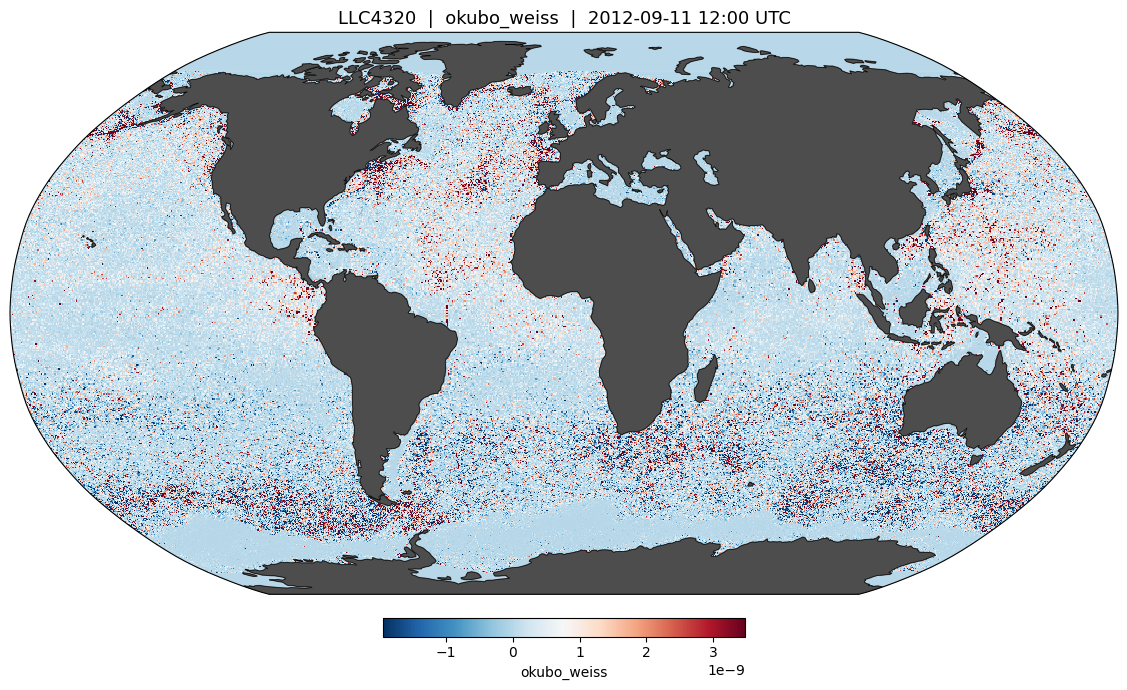

In [ ]:
# Percentile-based colour limits (robust to outliers)
vmin, vmax = np.nanpercentile(field_ds, [2, 98])

fig, ax = plt.subplots(
    figsize=(14, 7),
    subplot_kw={"projection": ccrs.Robinson()}
)
ax.set_global()
ax.add_feature(cfeature.LAND, color="0.3", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, zorder=2)

pcm = ax.pcolormesh(
    lon_ds, lat_ds, field_ds,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin, vmax=vmax,
    shading="auto",
    rasterized=True,
    zorder=0
)

plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.04,
             fraction=0.03, label=data_var)

ax.set_title(f"LLC4320  |  {data_var}  |  2012-09-11 12:00 UTC", fontsize=13)
plt.tight_layout()
plt.show()